In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# ========================================================================================================
# ⚜️ Carga de datos 
# ========================================================================================================
df = pd.read_csv("C:\\Users\\sebas\\OneDrive\\Desktop\\_SemestresCursados_\\5to_Semestre\\Mineria_Datos\\Talleres60x\\Aprendizaje_no_supervisado_Mineria\\Codigo_Datasets\\dataset_clustering.csv")
print(df)

# ========================================================================================================
# ⚜️ Redondear antes de convertir a int (por si acaso hay decimales)
# ========================================================================================================
df["MP"] = df["MP"].round().astype(int)

df["Gls"] = df["Gls"].round().astype(int)

df["Ast"] = df["Ast"].round().astype(int)
print("\nRedondeando: \n", df)

x = df[["MP", "Gls", "Ast"]]

        Age  MP   Min  CrdY  CrdR  PKatt  Gls  Ast   PK  Pos_encoded  \
0      22.0  20  1596  0.11   0.0    0.0  0.0  0.0  0.0            9   
1      35.0  22  1980  0.09   0.0    0.0  0.0  0.0  0.0            0   
2      23.0  14   770  0.12   0.0    0.0  0.0  0.0  0.0            9   
3      22.0  20  1799  0.15   0.0    0.0  1.0  1.0  0.0            7   
4      30.0  15  1165  0.16   0.0    0.0  1.0  1.0  0.0            7   
...     ...  ..   ...   ...   ...    ...  ...  ...  ...          ...   
10094  27.0  25  2084  4.00   0.0    0.0  5.0  1.0  0.0            7   
10095  27.0  18  1017  0.00   0.0    0.0  1.0  4.0  0.0            7   
10096  22.0   1    10  0.00   0.0    0.0  0.0  0.0  0.0            7   
10097  35.0   2    69  0.00   0.0    0.0  0.0  0.0  0.0            3   
10098  35.0  12    74  0.00   0.0    0.0  0.0  0.0  0.0            3   

       Comp_encoded  
0                 3  
1                 2  
2                 2  
3                 2  
4                 2  
...

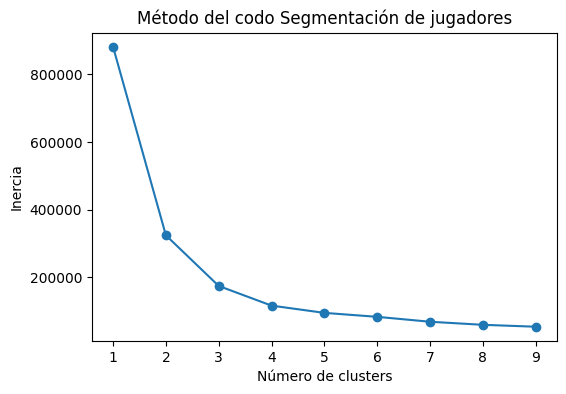

In [3]:
# ========================================================================================================
# ⚜️ Método del codo
# ========================================================================================================
inertias = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x)
    inertias.append(kmeans.inertia_)

plt. figure(figsize=(6,4))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo Segmentación de jugadores")
plt.show()

In [4]:
# ========================================================================================================
# ⚜️ Entrenar K-Means con k=3 (Por el método del codo) 
# ========================================================================================================
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x)

df["Cluster"] = kmeans.labels_

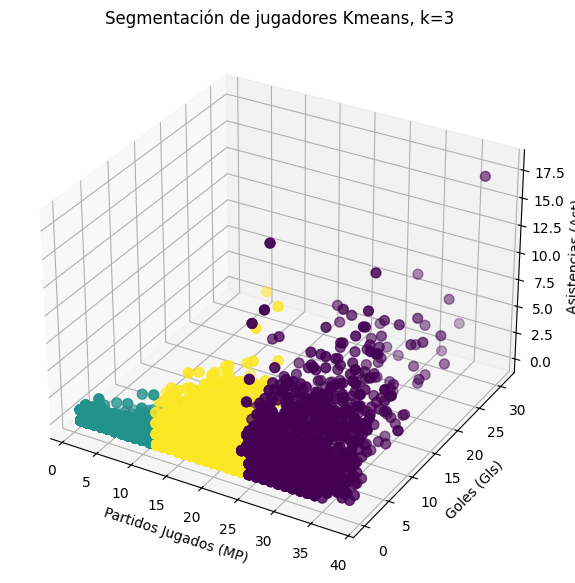

In [6]:
# ========================================================================================================
# ⚜️ Graficar en 3D sin anotaciones (labels)
# ========================================================================================================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Colocar colores a los clusters
sc = ax.scatter(df["MP"], df["Gls"], df["Ast"], 
                c=df["Cluster"], cmap="viridis", s=50)

# Etiquetas de ejes
ax.set_xlabel("Partidos Jugados (MP)")
ax.set_ylabel("Goles (Gls)")
ax.set_zlabel("Asistencias (Ast)")
plt.title("Segmentación de jugadores Kmeans, k=3")


plt.show()